# MonarchLinear + Sequential2D — Playground Notebook

A hands-on notebook for experimenting with **Monarch sparse linear layers** inside
the **Sequential2D** dynamical-systems framework.

The structure mirrors notebook 6 (*Sequential vs Sequential2D*) and the training
pipeline mirrors notebook 5 (*MLP*), so the patterns should feel familiar.

All key choices live in one **configuration cell** near the top — change those
and re-run to explore new ideas without touching the rest of the code.

**Sections**

1. Imports
2. Configuration (edit this to change the experiment)
3. Data Loading & Preprocessing
4. Build the Monarch-Sequential2D model
5. Training loop
6. Training history plot
7. Evaluation & accuracy
8. Bonus: compare Monarch with a dense (Linear) baseline

In [1]:
# Uncomment if running on Google Colab
# !pip install git+https://github.com/rcpaffenroth/generatedata
# !pip install git+https://github.com/rcpaffenroth/iterativennsimple

## 1. Imports

In [2]:
import copy

import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from generatedata.load_data import load_data
from generatedata.plot_2D_start_end import plot_2D_start_end

from iterativennsimple.MonarchLinear import MonarchLinear
from iterativennsimple.Sequential1D import Sequential1D
from iterativennsimple.Sequential2D import Sequential2D, Identity

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2. Configuration

**Edit this cell to change the experiment.**  Every other cell reads from `cfg`.

In [3]:
cfg = {
    # ---------------------------------------------------------------
    # Data
    # ---------------------------------------------------------------
    # Any name from generatedata.load_data.data_names() works here.
    # 'MNIST'           — 784-dim images, 10-class one-hot labels
    # 'circle'          — small 2D toy problem
    # 'regression_line' — simple 1D regression
    "dataset":        "MNIST",
    "one_hot_y":      True,   # True for classification datasets (MNIST)
    "max_samples":    1000,   # cap training set size (set to None to use all)

    # ---------------------------------------------------------------
    # Architecture  (the "hidden layers" between x and y)
    # ---------------------------------------------------------------
    # h_sizes: list of hidden-layer widths.
    # An empty list [] gives a single Monarch layer directly from x to y.
    "h_sizes":        [64, 64],

    # Monarch block count for every MonarchLinear in the model.
    # density = 1 / num_blocks   →   num_blocks=4 gives 75% sparsity.
    "num_blocks":     4,

    # Activation placed before each non-first Monarch layer.
    # Options: 'ReLU', 'ELU', 'Sigmoid', 'Identity'
    "activation":     "ReLU",

    # ---------------------------------------------------------------
    # Dynamical-system iteration count
    # ---------------------------------------------------------------
    # Number of times the block-map is applied per training step.
    # Must be >= len(h_sizes) + 1  to propagate signal to the output.
    "iterations":     3,

    # ---------------------------------------------------------------
    # Training
    # ---------------------------------------------------------------
    "batch_size":     256,
    "lr":             1e-3,
    "max_epochs":     200,
    "print_every":    50,    # print loss every N epochs (0 = silent)
}

print("Configuration loaded.")
print(f"  dataset   : {cfg['dataset']}")
print(f"  h_sizes   : {cfg['h_sizes']}")
print(f"  num_blocks: {cfg['num_blocks']}  (density = {1/cfg['num_blocks']:.0%}, sparsity ≈ {1-1/cfg['num_blocks']:.0%})")
print(f"  iterations: {cfg['iterations']}")

Configuration loaded.
  dataset   : MNIST
  h_sizes   : [64, 64]
  num_blocks: 4  (density = 25%, sparsity ≈ 75%)
  iterations: 3


## 3. Data Loading & Preprocessing

We use the same $z_0 / z_1$ split as notebook 5: columns that are **identical** across start and target are treated as $x$ (input features), while columns that **differ** are treated as $y$ (labels / outputs to learn).

In [4]:
def df_to_tensor(df) -> torch.Tensor:
    """Convert a pandas DataFrame to a float32 tensor."""
    return torch.tensor(df.values, dtype=torch.float32)


# --- load ---
data_dict = load_data(cfg["dataset"])
z_start  = df_to_tensor(data_dict["start"])
z_target = df_to_tensor(data_dict["target"])

# cap dataset size
if cfg["max_samples"] is not None:
    n = min(cfg["max_samples"], z_start.shape[0])
    z_start  = z_start[:n]
    z_target = z_target[:n]

print(f"Loaded '{cfg['dataset']}':  {z_start.shape[0]} samples, {z_start.shape[1]} total features")

# --- identify x (static) and y (changing) columns ---
# Columns that are the same in start and target → input features (x)
# Columns that differ                           → outputs to learn (y)
x_mask = (z_start == z_target).all(dim=0)
y_mask = ~x_mask

input_size  = int(x_mask.sum())
output_size = int(y_mask.sum())
print(f"  x (static)  : {input_size} features")
print(f"  y (changing): {output_size} features")

Loaded 'MNIST':  1000 samples, 794 total features
  x (static)  : 784 features
  y (changing): 10 features


In [5]:
# Build augmented state vectors  z_h = [x | h1 | h2 | … | y]
# Hidden layers are zero-initialised (they will be overwritten by the dynamics).
h_sizes     = cfg["h_sizes"]
total_h     = sum(h_sizes)

zh_start  = torch.cat([
    z_start[:, x_mask],
    torch.zeros(z_start.shape[0], total_h),
    z_start[:, y_mask],
], dim=1)

zh_target = torch.cat([
    z_target[:, x_mask],
    torch.zeros(z_target.shape[0], total_h),
    z_target[:, y_mask],
], dim=1)

# Index slices for later use
x_idx  = torch.arange(0, input_size)
h_idx  = torch.arange(input_size, input_size + total_h)
y_idx  = torch.arange(input_size + total_h, input_size + total_h + output_size)

print(f"Augmented state dimension: {zh_start.shape[1]}")
print(f"  x_idx : [{x_idx[0]}, {x_idx[-1]}]")
if total_h > 0:
    print(f"  h_idx : [{h_idx[0]}, {h_idx[-1]}]  (hidden)")
print(f"  y_idx : [{y_idx[0]}, {y_idx[-1]}]")

# DataLoader
class _PairDataset(torch.utils.data.Dataset):
    def __init__(self, s, t):
        self.s, self.t = s, t
    def __len__(self):
        return len(self.s)
    def __getitem__(self, i):
        return self.s[i], self.t[i]

train_loader = torch.utils.data.DataLoader(
    _PairDataset(zh_start, zh_target),
    batch_size=cfg["batch_size"],
    shuffle=True,
)

Augmented state dimension: 922
  x_idx : [0, 783]
  h_idx : [784, 911]  (hidden)
  y_idx : [912, 921]


## 4. Build the Monarch-Sequential2D Model

We encode the MLP-as-dynamical-system pattern as a strictly lower-triangular block matrix:

$$
\begin{bmatrix}
I   & 0   & \cdots & 0 \\
M_1 & 0   & \cdots & 0 \\
0   & M_2 & \cdots & 0 \\
\vdots &   & \ddots & \vdots \\
0   & 0   & M_k & 0 \\
\end{bmatrix}
$$

where each $M_i$ is a `MonarchLinear` layer and $I$ is the identity on $x$.

`build_monarch_model` is a small factory function — change it to explore different connectivity patterns.

In [6]:
def _make_monarch_block(in_f: int, out_f: int, num_blocks: int,
                         activation: str | None = None) -> nn.Module:
    """Return a MonarchLinear (optionally wrapped with an activation).

    When activation is given it is placed *before* the linear transform,
    matching the pattern in notebook 6.
    """
    layer = MonarchLinear.from_uniform_blocks(
        in_features=in_f,
        out_features=out_f,
        num_blocks=num_blocks,
        bias=True,
    )
    if activation is None or activation == "Identity":
        return Sequential1D(nn.Sequential(layer), in_features=in_f, out_features=out_f)

    act_map = {"ReLU": nn.ReLU, "ELU": nn.ELU, "Sigmoid": nn.Sigmoid}
    act = act_map[activation]()
    return Sequential1D(nn.Sequential(act, layer), in_features=in_f, out_features=out_f)


def build_monarch_model(
    input_size: int,
    h_sizes: list[int],
    output_size: int,
    num_blocks: int,
    activation: str = "ReLU",
) -> Sequential2D:
    """Build an MLP-as-dynamical-system using MonarchLinear blocks.

    The state vector is  [x | h1 | h2 | … | hk | y].
    The block matrix is strictly lower-triangular:

        row 0 (x)  → I  (identity, no learning)
        row 1 (h1) ← MonarchLinear(x  → h1),  no activation on first layer
        row 2 (h2) ← MonarchLinear(h1 → h2),  with activation
        ...
        row k (y)  ← MonarchLinear(hk → y),   with activation

    Args:
        input_size:  Dimension of x.
        h_sizes:     Width of each hidden layer.  Can be empty for a direct map.
        output_size: Dimension of y.
        num_blocks:  Number of Monarch blocks per layer.
        activation:  Non-linearity inserted before each non-first Monarch layer.

    Returns:
        A Sequential2D ready for training.
    """
    layer_sizes = [input_size] + h_sizes + [output_size]
    n = len(layer_sizes)     # number of "slots" in the state vector

    in_features_list  = layer_sizes
    out_features_list = layer_sizes

    # Build the Identity at position (0,0)
    I = Identity(in_features=input_size, out_features=input_size)

    # Build Monarch blocks on the sub-diagonal
    monarch_blocks: list[nn.Module] = []
    for i in range(n - 1):
        in_f  = layer_sizes[i]
        out_f = layer_sizes[i + 1]
        # No activation for the very first layer (it reads raw x)
        act = None if i == 0 else activation
        # Ensure num_blocks divides both dimensions; fall back if needed
        nb = num_blocks
        while in_f % nb != 0 or out_f % nb != 0:
            nb -= 1
            if nb < 1:
                nb = 1
                break
        monarch_blocks.append(_make_monarch_block(in_f, out_f, nb, act))

    # Assemble the block matrix  (transposed: Sequential2D uses left-multiply)
    # blocks[i][j] maps slot i  →  slot j
    blocks = [[None] * n for _ in range(n)]
    blocks[0][0] = I
    for i in range(n - 1):
        blocks[i][i + 1] = monarch_blocks[i]

    return Sequential2D(in_features_list, out_features_list, blocks)


# --- build ---
model = build_monarch_model(
    input_size=input_size,
    h_sizes=cfg["h_sizes"],
    output_size=output_size,
    num_blocks=cfg["num_blocks"],
    activation=cfg["activation"],
).to(device)

total_params = model.number_of_trainable_parameters()
print(model)
print(f"\nTrainable parameters: {total_params:,}")

Sequential2D(
  (blocks): ModuleDict(
    ((0, 0)): Identity()
    ((0, 1)): Sequential1D(
      (0): Sequential(
        (0): MonarchLinear(
          in_features=784, out_features=64, num_blocks=4, bias=True
          (blocks): ParameterList(
              (0): Parameter containing: [torch.float32 of size 16x196 (cuda:0)]
              (1): Parameter containing: [torch.float32 of size 16x196 (cuda:0)]
              (2): Parameter containing: [torch.float32 of size 16x196 (cuda:0)]
              (3): Parameter containing: [torch.float32 of size 16x196 (cuda:0)]
          )
        )
      )
    )
    ((1, 2)): Sequential1D(
      (0): Sequential(
        (0): ReLU()
        (1): MonarchLinear(
          in_features=64, out_features=64, num_blocks=4, bias=True
          (blocks): ParameterList(
              (0): Parameter containing: [torch.float32 of size 16x16 (cuda:0)]
              (1): Parameter containing: [torch.float32 of size 16x16 (cuda:0)]
              (2): Parameter conta

## 5. Training Loop

Each epoch applies the block map `cfg['iterations']` times before computing the loss on the $y$ slots only.

In [7]:
def train(
    model: Sequential2D,
    loader: torch.utils.data.DataLoader,
    y_idx: torch.Tensor,
    iterations: int,
    lr: float,
    max_epochs: int,
    print_every: int = 50,
) -> list[float]:
    """Train model and return per-epoch mean loss history.

    Args:
        model:       The Sequential2D model.
        loader:      DataLoader yielding (start, target) batches.
        y_idx:       Column indices of the y (output) slot.
        iterations:  Number of times to apply the block map per step.
        lr:          Learning rate for Adam.
        max_epochs:  Number of training epochs.
        print_every: Print loss every this many epochs (0 = never).

    Returns:
        List of per-epoch mean MSE loss values.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history: list[float] = []

    # Move y_idx to the same device as the model
    y_idx_dev = y_idx.to(next(model.parameters()).device)

    for epoch in range(1, max_epochs + 1):
        epoch_loss = 0.0
        for start_batch, target_batch in loader:
            start_batch  = start_batch.to(device)
            target_batch = target_batch.to(device)

            optimizer.zero_grad()

            state = start_batch
            for _ in range(iterations):
                state = model(state)

            loss = criterion(state[:, y_idx_dev], target_batch[:, y_idx_dev])
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        mean_loss = epoch_loss / len(loader)
        history.append(mean_loss)

        if print_every > 0 and epoch % print_every == 0:
            print(f"  Epoch {epoch:4d}/{max_epochs}  loss = {mean_loss:.6f}")

    return history


print("Training Monarch model …")
history = train(
    model=model,
    loader=train_loader,
    y_idx=y_idx,
    iterations=cfg["iterations"],
    lr=cfg["lr"],
    max_epochs=cfg["max_epochs"],
    print_every=cfg["print_every"],
)
print(f"Final loss: {history[-1]:.6f}")

Training Monarch model …
  Epoch   50/200  loss = 0.024902
  Epoch  100/200  loss = 0.014291
  Epoch  150/200  loss = 0.009639
  Epoch  200/200  loss = 0.007036
Final loss: 0.007036


## 6. Training History Plot

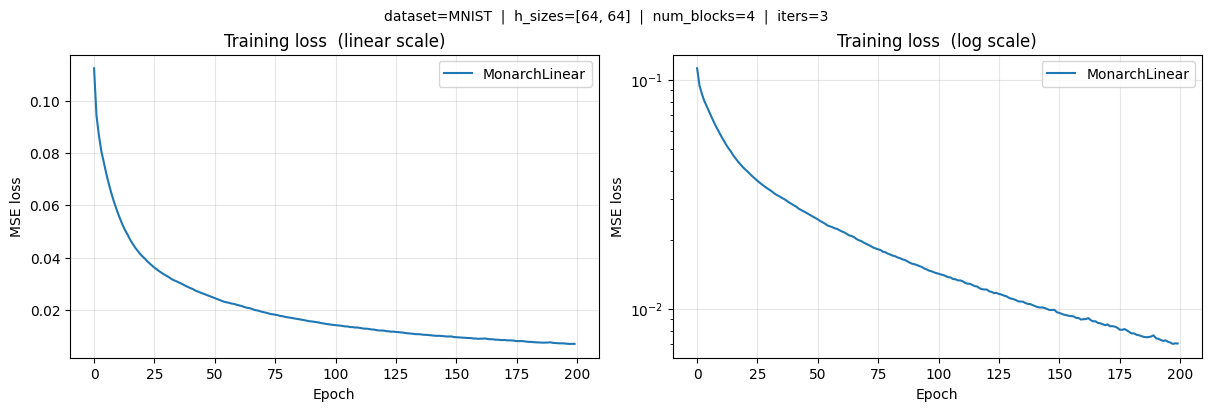

In [8]:
def plot_history(histories: dict[str, list[float]], title: str = "Training loss") -> None:
    """Plot one or more loss curves on a single figure.

    Args:
        histories: Mapping from label string to list of per-epoch losses.
        title:     Figure title.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

    for label, h in histories.items():
        axes[0].plot(h,              label=label)
        axes[1].semilogy(h,          label=label)

    for ax, yscale in zip(axes, ["linear", "log"]):
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE loss")
        ax.set_title(f"{title}  ({yscale} scale)")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"dataset={cfg['dataset']}  |  h_sizes={cfg['h_sizes']}  |  "
        f"num_blocks={cfg['num_blocks']}  |  iters={cfg['iterations']}",
        fontsize=10,
    )
    plt.show()


plot_history({"MonarchLinear": history})

## 7. Evaluation

For classification datasets (`one_hot_y=True`) we compute accuracy via argmax.
For regression datasets we report MSE on the training set.

In [9]:
@torch.no_grad()
def evaluate(
    model: Sequential2D,
    zh_start: torch.Tensor,
    zh_target: torch.Tensor,
    y_idx: torch.Tensor,
    iterations: int,
    one_hot_y: bool = False,
) -> dict:
    """Run a full-dataset forward pass and compute metrics.

    Returns:
        dict with 'mse' and (if one_hot_y) 'accuracy'.
    """
    model.eval()
    state = zh_start.to(device)
    y_idx_dev = y_idx.to(device)

    for _ in range(iterations):
        state = model(state)

    predicted_y = state[:, y_idx_dev].cpu()
    target_y    = zh_target[:, y_idx]

    mse = nn.MSELoss()(predicted_y, target_y).item()
    results: dict = {"mse": mse}

    if one_hot_y:
        pred_class   = predicted_y.argmax(dim=1)
        target_class = target_y.argmax(dim=1)
        accuracy = (pred_class == target_class).float().mean().item()
        results["accuracy"] = accuracy

    model.train()
    return results


metrics = evaluate(
    model, zh_start, zh_target, y_idx,
    iterations=cfg["iterations"],
    one_hot_y=cfg["one_hot_y"],
)

print(f"Training-set MSE      : {metrics['mse']:.6f}")
if "accuracy" in metrics:
    print(f"Training-set accuracy : {metrics['accuracy']:.2%}")

Training-set MSE      : 0.006926
Training-set accuracy : 99.80%


## 8. Bonus: Monarch vs Dense Baseline

Build an identical dynamical-system architecture but replace every `MonarchLinear`
with a standard `nn.Linear` (dense).  Train both from scratch and overlay their
loss curves — this makes it easy to assess the quality / speed trade-off introduced
by the sparse Monarch structure.

In [10]:
def build_dense_model(
    input_size: int,
    h_sizes: list[int],
    output_size: int,
    activation: str = "ReLU",
) -> Sequential2D:
    """Same architecture as build_monarch_model but with dense nn.Linear blocks.

    Useful as a parameter-count upper bound and accuracy reference.
    """
    act_map = {"ReLU": nn.ReLU, "ELU": nn.ELU, "Sigmoid": nn.Sigmoid, "Identity": nn.Identity}
    layer_sizes = [input_size] + h_sizes + [output_size]
    n = len(layer_sizes)

    I = Identity(in_features=input_size, out_features=input_size)

    linear_blocks: list[nn.Module] = []
    for i in range(n - 1):
        in_f, out_f = layer_sizes[i], layer_sizes[i + 1]
        lin = nn.Linear(in_f, out_f)
        if i == 0:
            block = Sequential1D(nn.Sequential(lin), in_features=in_f, out_features=out_f)
        else:
            act = act_map[activation]()
            block = Sequential1D(nn.Sequential(act, lin), in_features=in_f, out_features=out_f)
        linear_blocks.append(block)

    blocks = [[None] * n for _ in range(n)]
    blocks[0][0] = I
    for i in range(n - 1):
        blocks[i][i + 1] = linear_blocks[i]

    return Sequential2D(layer_sizes, layer_sizes, blocks)


# --- build and train both models from scratch ---
model_monarch = build_monarch_model(
    input_size, cfg["h_sizes"], output_size,
    num_blocks=cfg["num_blocks"], activation=cfg["activation"],
).to(device)

model_dense = build_dense_model(
    input_size, cfg["h_sizes"], output_size,
    activation=cfg["activation"],
).to(device)

print(f"Monarch params : {model_monarch.number_of_trainable_parameters():,}")
print(f"Dense params   : {sum(p.numel() for p in model_dense.parameters() if p.requires_grad):,}")

print("\nTraining Monarch …")
hist_monarch = train(model_monarch, train_loader, y_idx,
                     cfg["iterations"], cfg["lr"], cfg["max_epochs"],
                     print_every=cfg["print_every"])

print("\nTraining Dense …")
hist_dense   = train(model_dense,   train_loader, y_idx,
                     cfg["iterations"], cfg["lr"], cfg["max_epochs"],
                     print_every=cfg["print_every"])

Monarch params : 14,026
Dense params   : 55,050

Training Monarch …
  Epoch   50/200  loss = 0.027813
  Epoch  100/200  loss = 0.016572
  Epoch  150/200  loss = 0.011704
  Epoch  200/200  loss = 0.008714

Training Dense …
  Epoch   50/200  loss = 0.011455
  Epoch  100/200  loss = 0.004571
  Epoch  150/200  loss = 0.002166
  Epoch  200/200  loss = 0.001164


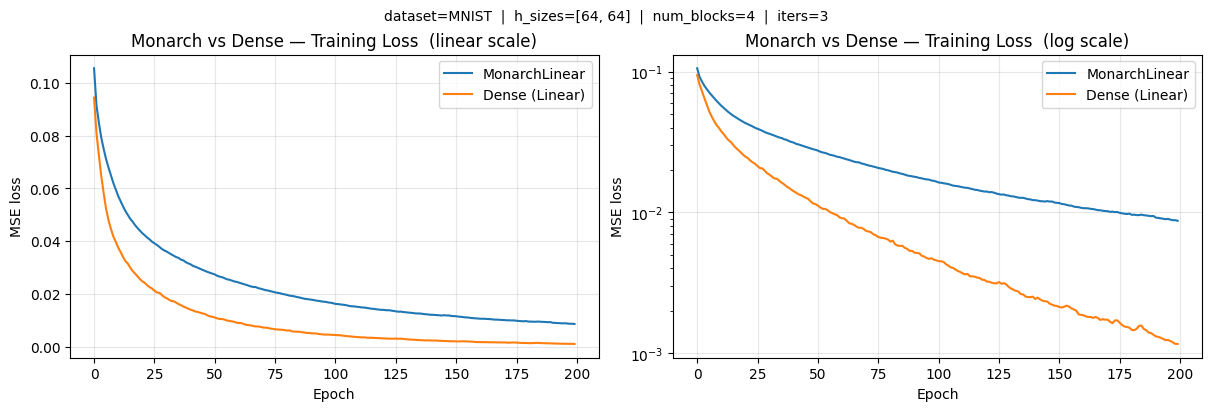

In [11]:
plot_history({"MonarchLinear": hist_monarch, "Dense (Linear)": hist_dense},
             title="Monarch vs Dense — Training Loss")

In [12]:
# Summary: evaluate both models on the training set
m_metrics = evaluate(model_monarch, zh_start, zh_target, y_idx,
                     cfg["iterations"], cfg["one_hot_y"])
d_metrics = evaluate(model_dense,   zh_start, zh_target, y_idx,
                     cfg["iterations"], cfg["one_hot_y"])

print("=" * 50)
print(f"{'Model':<20} {'Params':>10}  {'MSE':>10}  {'Accuracy':>10}")
print("-" * 50)
print(f"{'MonarchLinear':<20} "
      f"{model_monarch.number_of_trainable_parameters():>10,}  "
      f"{m_metrics['mse']:>10.6f}  "
      f"{m_metrics.get('accuracy', float('nan')):>10.2%}")
print(f"{'Dense (Linear)':<20} "
      f"{sum(p.numel() for p in model_dense.parameters() if p.requires_grad):>10,}  "
      f"{d_metrics['mse']:>10.6f}  "
      f"{d_metrics.get('accuracy', float('nan')):>10.2%}")
print("=" * 50)

Model                    Params         MSE    Accuracy
--------------------------------------------------
MonarchLinear            14,026    0.008673      99.50%
Dense (Linear)           55,050    0.001128     100.00%


---

## Ideas to Explore

All changes can be made by editing the **configuration cell** and re-running:

| Idea | What to change |
|------|----------------|
| Fewer parameters | increase `num_blocks` (e.g. 8, 16) |
| Deeper network | add entries to `h_sizes` |
| Different dataset | change `dataset` to `'circle'`, `'MNIST1D'`, etc. |
| More iterations | increase `iterations` (helps signal propagate) |
| Different sparsity | `num_blocks=2` ≈ 50% sparse, `num_blocks=8` ≈ 87.5% sparse |
| Different activation | change `activation` to `'ELU'` or `'Sigmoid'` |

To experiment with **non-uniform block sizes** or **mixed monarch/dense** layers,
edit `build_monarch_model` directly — it is designed to be simple to modify.